In [3]:
from collections import OrderedDict
from collections import namedtuple
import os
import copy
import mne
from mne.stats import linear_regression, fdr_correction
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pingouin import rm_anova, ttest
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from re import findall
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [4]:
class subject:
    def __init__(self, list_num, eeglab_elist, BDF_txt, mne_raw):
        self.list_num = list_num
        self.eeglab_elist = eeglab_elist
        self.BDF_txt = BDF_txt
        self.mne_raw = mne_raw
        
    def load_unique_codes(self, uc1, uc2):
        if self.list_num == 1: return [str(i) for i in uc1.flatten()]
        elif self.list_num == 2: return [str(i) for i in uc2.flatten()]
        else: return None
    
    def load_predictors(self, df_pred1, df_pred2, drop_col=[]):
        if self.list_num == 1:
            if drop_col != []: df_pred1.drop(df_pred1.columns[drop_col], axis=1, inplace=True)
            return df_pred1.to_numpy()
        
        elif self.list_num == 2:
            if drop_col != []: df_pred2.drop(df_pred2.columns[drop_col], axis=1, inplace=True)
            return df_pred2.to_numpy()
            
        else: return None
    
    def parse_bdf(self):
        f1 = open(self.BDF_txt, 'r')
        f2 = f1.read().split()
        f1.close()
        ev_seq = [f2[3+4*i] for i in range(int((len(f2))/4))]
        tlock = [i.split('.') for i in ev_seq]
        
        parse1 = [[[] for j in i] for i in tlock]
        for i in range(len(tlock)):
            for j, y in enumerate(tlock[i]):
                parse1[i][j] = y.split('}')[:-1]
        
        parse2 = [[[] for j in i] for i in tlock]
        for i in range(len(tlock)):
            for j, y in enumerate(parse1[i]):
                for k, z in enumerate(y):
                    if '-' in z:
                        l = int(findall(r'\d+', z)[0])
                        u = int(findall(r'\d+', z)[1])
                        parse2[i][j].append([str(n) for n in list(range(l, u+1))])
                    else: parse2[i][j].append(findall(r'\d+', z))
        return parse2
    
    def split_elist(self):
        f1 = open(self.eeglab_elist, 'r')
        f2 = f1.readlines()
        f1.close
        f3 = [i.split() for i in f2]
        return f3
    
    def AD_compiled_epoching(self, tmin=0.1, tmax=1, bc=(0.1,1)):
        f3 = self.split_elist()
        marked = [i[2]+'bad' if int(i[8]) != 0 else i[2] for i in f3]
        
        bdf = self.parse_bdf()
        annot = copy.deepcopy(self.mne_raw.annotations)
        items = {}
        for j, key in enumerate(annot[0].keys()): items[key] = []
        for i in range(len(annot)):
            for j, key in enumerate(annot[i].keys()):
                items[key].append(annot[i][key])
        
        ev = [bdf[i][1][0] for i in range(len(bdf))]
        bins = [str(n) for n in list(range(301, 301+len(bdf)))]
        
        for i in range(len(bdf)):
            for j in range(len(annot)):
                if annot[j]['description'] in bdf[i][1][0]:    # if the event code is the event time-locked to
                    boo = [[[] for k in j] for j in bdf[i]]
                    temp = [[True for k in j] for j in bdf[i]]
                    for k, z in enumerate(bdf[i][0]):
                        try:
                            if annot[j-(len(bdf[i][0])-k)]['description'] in z: boo[0][k] = True
                            else: boo[0][k] = False
                        except IndexError:
                            boo[0] = None
                            break
                    for k, z in enumerate(bdf[i][1]):
                        try:
                            if annot[j+k]['description'] in z: boo[1][k] = True
                            else: boo[1][k] = False
                        except IndexError:
                            boo[1] = None
                            break
                    if boo == temp: items['description'][j] = bins[i]
                    
        ev_arr, ev_dict = mne.events_from_annotations(self.mne_raw, event_id='auto')
        for i, x in enumerate(items['description']):
            try:
                if x in bins: ev_arr[i][2] = int(x)
            except: 
                pass
                
        for i, x in enumerate(marked):
            if 'bad' in x: items['description'][i]  += 'bad'
        tlock_events = [i for i in items['description'] if findall(r'\d+', i) in [[n] for n in bins]]
        description = copy.deepcopy(items['description'])
        
        items['description'] = ['bad_blink' if 'bad' in i else i for i in items['description']]
        new_annot = mne.Annotations(np.array(items['onset'], dtype=object),
                                    np.array(items['duration'], dtype=object),
                                    np.array(items['description'], dtype=object), orig_time=None, ch_names=None)
        new_raw = raw.copy().set_annotations(new_annot)
        epoch = mne.Epochs(new_raw, ev_arr, event_id=[int(n) for n in bins], tmin=tmin, tmax=tmax, baseline=bc,
                           reject_by_annotation=True)
        
        AD_Compiled = namedtuple('AD_Compiled', ['Epoch', 'Description', 'Tlock_Events'])
        ad_compiled = AD_Compiled(epoch, description, tlock_events)
        return ad_compiled
    
    def check_parse(self):
        '''Might only work for certain/simpler kinds of bin descriptor files, e.g., Crystal's 8 bins'''
        f3 = self.split_elist()
        parsed = self.parse_bdf()
        
        ecodes = sum([p[1][0] for p in parsed], [])
        trials = [[f[2], f[8]] for f in f3 if f[2] in ecodes]
        
        convert_dict = {}
        for i, key in enumerate(ecodes): convert_dict[key] = str(301+i)
        to_check = [convert_dict[i[0]] if int(i[1])==0 else convert_dict[i[0]]+'bad' for i in trials]
        tlock_events = self.AD_compiled_epoching().Tlock_Events
        
        print('\nEpochs correctly created in MNE\n') if to_check==tlock_events else print('\nOoops, it seems your epohcs are incorrect... breaking from theh loop\n')
        return to_check==tlock_events
    
    def check_elist(self, description, tlock_events, uc1, uc2):  
        unique_codes = self.load_unique_codes(uc1, uc2)
        prefinal = [description[i-1] for i in range(len(description)) if description[i] in tlock_events]
        check = False
        if len(prefinal) == len(unique_codes):
            check = [bool(prefinal[i] == unique_codes[i]) for i in range(len(prefinal))]
            if False in check: return prefinal, unique_codes
            else:
                return None
        else: return prefinal, unique_codes
    
    def sort_predictors(self, df_pred1, df_pred2, description, tlock_events, uc1, uc2):
        predictors = self.load_predictors(df_pred1, df_pred2, drop_col=[])
        check = self.check_elist(description, tlock_events, uc1, uc2)
        if check == None: return predictors
        else:
            prefinals, unique_codes = check
            idx = None
            for i in range(len(unique_codes)):
                if unique_codes[i] == prefinals[0]:
                    idx = i
                    break
            predictors = np.concatenate((predictors[idx:], predictors[0:idx]), axis=0)
            return predictors
        
    def get_design_matrix(self, df_pred1, df_pred2, description, tlock_events, uc1, uc2):
        predictors = self.sort_predictors(df_pred1, df_pred2, description, tlock_events, uc1, uc2)
        predictors = np.insert(predictors, 0, 1, axis=1)
        dmatrix = np.zeros((0, np.shape(predictors)[1]))
        for i, x in enumerate(tlock_events):
            if 'bad' not in x: dmatrix = np.r_[dmatrix, [predictors[i]]]
        return dmatrix
    
    def get_chan_dict(self):
        ch_list = self.mne_raw.ch_names
        ch_dict = OrderedDict()
        for i in range(len(ch_list)): ch_dict.update({ch_list[i]: i})
        return ch_dict     

In [5]:
def OLS_solution(X):
    X_t = np.transpose(X)
    XX_t = np.matmul(X_t, X)
    inv_XX_t = np.linalg.inv(XX_t)
    X_t = np.transpose(X)
    XX_t = np.matmul(X_t, X)
    inv_XX_t = np.linalg.inv(XX_t)
    sol = np.matmul(inv_XX_t, X_t)
    return sol

def rerp_ols(mne_epoch, X, pred_names=None):
    try:
        num_coef = X.shape[1]
        if pred_names == None:
            pred_names = ['x'+str(i) for i in range(num_coef)]
            
        rERP_OLS_Wrapper = namedtuple('rERP_OLS_Wrapper', ['Coeffs', 'Fitted', 'Resids'])
        Coeffs_Info = namedtuple('Coeffs_Info', ['beta', 'tval', 'pval'])
    
        data = mne_epoch.copy().get_data()
        num_ep, num_ch, num_t = np.shape(data)
    
        coeffs = np.empty((num_coef, num_ch, num_t))
        fitted, resids = np.empty((num_ep, num_ch, num_t)), np.empty((num_ep, num_ch, num_t))
    
        sol = OLS_solution(X)
        for ch in range(num_ch):
            y = data[:,ch,:]
            coeffs[:,ch,:] = np.matmul(sol, y)
            fitted[:,ch,:] = np.matmul(X, coeffs[:,ch,:])
            resids[:,ch,:] = np.subtract(y, fitted[:,ch,:])
    
        beta, tval, pval = np.empty((num_coef, num_ch, num_t)), np.empty((num_coef, num_ch, num_t)), np.empty((num_coef, num_ch, num_t))

        rerp = linear_regression(mne_epoch, X, names=pred_names)
        for i in range(len(pred_names)):
            beta[i], tval[i], pval[i] = rerp[pred_names[i]].beta.data, rerp[pred_names[i]].t_val.data, rerp[pred_names[i]].p_val.data
        
        coeffs_dict = {'coeffs_arr': coeffs}
        for i in range(len(pred_names)):
            coeffs_dict[pred_names[i]] = Coeffs_Info(beta[i], tval[i], pval[i])
        
        rerp_ols_wrapper = rERP_OLS_Wrapper(coeffs_dict, fitted, resids)
    except AttributeError:
        return None
    else:    
        return rerp_ols_wrapper

def mV(arr):
    arr = np.multiply(arr, 10**6)
    return arr

In [6]:
class rERP(subject):
    def __init__(self, list_num, eeglab_elist, BDF_txt, mne_raw, epoch, dmatrix):
        super().__init__(list_num, eeglab_elist, BDF_txt, mne_raw)
        self.epoch = epoch
        self.dmatrix = dmatrix
        
    def compute_ERPs(self, binlabels=None):
        bdf = self.parse_bdf()
        bins = [str(n) for n in list(range(301, 301+len(bdf)))]
        data, annot = self.epoch.copy().get_data(), self.epoch.annotations
        ev_codes = [annot[i]['description'] for i in range(len(annot)) if annot[i]['description'] in bins]
        
        dmatrix_bin = np.zeros((data.shape[0], len(bdf)))
        for i in range(data.shape[0]):
            for j in range(len(bins)):
                if ev_codes[i] == bins[j]: dmatrix_bin[i][j] = 1
        ERPs = rerp_ols(self.epoch, dmatrix_bin, pred_names=binlabels)
        return ERPs
    
    def compute_rERPs(self, pred_names=None):
        rERPs = rerp_ols(self.epoch, self.dmatrix, pred_names=pred_names)
        return rERPs
    
    def get_rerp_outputs(self, binlabels=None, pred_names=None):
        Outputs = namedtuple('Outputs', ['ERPs', 'rERPs'])
        erp, rerp = self.compute_ERPs(binlabels=binlabels), self.compute_rERPs(pred_names=pred_names)
        outputs = Outputs(erp, rerp)
        return outputs
    
    def compute_bin_avg_rERPs(self, rERPs, binlabels=None):
        '''Not really a useful function'''
        bdf = self.parse_bdf()
        bins = [str(n) for n in list(range(301, 301+len(bdf)))]
        fitted, resids, annot = rERPs.Fitted, rERPs.Resids, self.epoch.annotations
        ev_codes = [annot[i]['description'] for i in range(len(annot)) if annot[i]['description'] in bins]
        
        dmatrix_bin = np.zeros((fitted.shape[0], len(bdf)))
        for i in range(fitted.shape[0]):
            for j in range(len(bins)):
                if ev_codes[i] == bins[j]: dmatrix_bin[i][j] = 1
                
        num_bins, num_ch, num_t = len(bins), fitted.shape[1], fitted.shape[2]
        
        bin_avg_fitted, bin_avg_resids = np.empty((num_bins, num_ch, num_t)), np.empty((num_bins, num_ch, num_t))
        sol = OLS_solution(dmatrix_bin)
        for ch in range(num_ch):
            y1, y2 = fitted[:,ch,:], resids[:,ch,:]
            bin_avg_fitted[:,ch,:], bin_avg_resids[:,ch,:] = np.matmul(sol, y1), np.matmul(sol, y2)
        
        Bin_Avg_rERPs = namedtuple('Bin_Avg_rERPs', ['Fitted', 'Resids'])
        bin_avg_rerps = Bin_Avg_rERPs(bin_avg_fitted, bin_avg_resids)
        return bin_avg_rerps
    
    def roi_func(self, coeffs, tmin, tmax, step, chan_groups):
        num_coef, tmin, tmax = coeffs.shape[0], tmin+100, tmax+100
        chan_dict = self.get_chan_dict()
        chan_groups_idx = [(lambda grp: [chan_dict[names] for names in grp])(grp) for grp in chan_groups]
        
        avg_across_chan = np.zeros((num_coef, len(chan_groups), tmax-tmin))
        for i, grp in enumerate(chan_groups_idx):
            for j in grp:
                avg_across_chan[:,i,:] += coeffs[:,j,tmin:tmax]
            avg_across_chan[:,i,:] = np.multiply(avg_across_chan[:,i,:], 1/len(grp))
            
        num_t = int((tmax-tmin)/step)
        roi = np.zeros((num_coef, len(chan_groups), num_t))
        for i in range(num_t):
            for j in range(step):
                roi[:,:,i] += avg_across_chan[:,:,i*step+j]
            roi[:,:,i] = np.multiply(roi[:,:,i], 1/step)
        return roi
    
    def get_roi_coeffs(self, outputs, tmin, tmax, step, chan_groups, mode=None):
        if mode == 'ERP': coeffs = outputs.ERPs.Coeffs['coeffs_arr']
        elif mode == 'rERP': coeffs = outputs.rERPs.Coeffs['coeffs_arr']
        else: coeffs = None
        
        if coeffs is not None:
            roi = self.roi_func(coeffs, tmin, tmax, step, chan_groups)
            return roi
        else: print('mode is either ERP or rERP')

In [7]:
def compute_grand_avgs(subj_outputs):
    Grand_Avgs = namedtuple('Grand_Avgs', ['ERPs', 'rERPs'])
    num_subj = len(subj_outputs)
    num_bins, num_ch, num_t = subj_outputs[0].ERPs.Coeffs['coeffs_arr'].shape
    try:
        num_coef = subj_outputs[0].rERPs.Coeffs['coeffs_arr'].shape[0]
    
        gnd_avgs = np.array([np.zeros((num_bins, num_ch, num_t)),                  # grand average ERPs
                             np.zeros((num_coef, num_ch, num_t))], dtype=object)   # grand average rERP coefficients 
    
        for i in range(num_subj):
            gnd_avgs[0] += subj_outputs[i].ERPs.Coeffs['coeffs_arr']
            gnd_avgs[1] += subj_outputs[i].rERPs.Coeffs['coeffs_arr']
        gnd_avgs = np.multiply(gnd_avgs, 1/num_subj)

        grand_avgs = Grand_Avgs(gnd_avgs[0], gnd_avgs[1])
    except AttributeError:
        gnd_avgs = np.array([np.zeros((num_bins, num_ch, num_t)),
                             np.zeros((num_bins, num_ch, num_t))], dtype=object)
        for i in range(num_subj):
            gnd_avgs[0] += subj_outputs[i].ERPs.Coeffs['coeffs_arr']
        gnd_avgs = np.multiply(gnd_avgs, 1/num_subj)
    else:
        pass
    finally:
        grand_avgs = Grand_Avgs(gnd_avgs[0], gnd_avgs[1])
        return grand_avgs

In [8]:
class stats_and_graphs:
    def __init__(self, chan_dict, bins_dict, effects_dict, subj_outputs, subj_rerp_roi, grand_avgs):
        self.chan_dict = chan_dict
        self.bins_dict = bins_dict
        self.effects_dict = effects_dict
        self.subj_outputs = subj_outputs
        self.subj_rerp_roi = subj_rerp_roi
        self.grand_avgs = grand_avgs
        
    def coeff_formatting(self):
        N = len(self.subj_outputs)
        coeffs = np.empty((N, self.subj_rerp_roi[0].shape[0], self.subj_rerp_roi[0].shape[1], self.subj_rerp_roi[0].shape[2]))
        for i in range(N):
            coeffs[i] = self.subj_rerp_roi[i]
        return coeffs
        
    def ttest(self, coeffs):
        zeros = np.zeros((coeffs.shape[0], coeffs.shape[1], coeffs.shape[2], coeffs.shape[3]))  # (num_subj, num_coef, num_ch, num_t)
        
        tval = np.empty((coeffs.shape[1], coeffs.shape[2], coeffs.shape[3]))
        pval = np.empty((coeffs.shape[1], coeffs.shape[2], coeffs.shape[3]))
        for i in range(np.shape(coeffs)[1]):
            tval[i], pval[i] = ttest_ind(coeffs[:,i,:,:], zeros[:,i,:,:], axis=0, alternative='two-sided')
        return (tval, pval)
    
    def fdr_BH(self, p_un, alpha=0.05):
        dim1, dim2, dim3 = p_un.shape
    
        fdr = [fdr_correction(p_un[i].flatten(), alpha=alpha, method='indep') for i in range(dim1)]
        rej, qval = np.empty((dim1, dim2, dim3)), np.empty((dim1, dim2, dim3))
        for i, tup in enumerate(fdr):
            rej[i] = tup[0].reshape(p_un[i].shape[0], p_un[i].shape[1])
            qval[i] = tup[1].reshape(p_un[i].shape[0], p_un[i].shape[1])
        rej = 1*~rej.astype(bool)
                    
        FDR = namedtuple('FDR', ['Rej', 'Qval'])
        fdr = FDR(rej, qval)
        return fdr
    
    def plot_grand_averages(self, title, mode, row=0, col=0, figsize=None, bins=None, effects=None,
                                  linestyles=[], colors=[], chan_list=[], baseline=-100):
            num_t = self.subj_outputs[0].rERPs.Coeffs['coeffs_arr'].shape[2]
            t = [i for i in range(baseline, num_t+baseline)]
            chan_arr = np.array(chan_list).reshape(row, col)
            
            try:
                figure, axis = plt.subplots(row, col, figsize=figsize)
                Axes = axis.copy().flatten() if len(chan_arr) > 1 else axis
                try:
                    for ax, ch in zip(Axes, chan_arr.copy().flatten()):
                        if mode == 'ERP':
                            for i, x in enumerate(bins):
                                ax.plot(t, mV(self.grand_avgs.ERPs[self.bins_dict[x]][self.chan_dict[ch]]),
                                        linestyle=linestyles[i], color=colors[i], label=x)
                        elif mode == 'rERP':
                            for i, x in enumerate(effects):
                                ax.plot(t, mV(self.grand_avgs.rERPs[self.effects_dict[x]][self.chan_dict[ch]]),
                                        linestyle=linestyles[i], color=colors[i], label=x)
                        ax.axvline(x=0, color='black', linewidth=0.5)
                        ax.axhline(y=0, color='black', linewidth=0.5)
                        ax.set_title(ch)
                        ax.set_xlabel('Time (ms)')
                        ax.set_ylabel('µV')
                        ax.invert_yaxis()
                        hdl, lbl = ax.get_legend_handles_labels()
                except TypeError:
                    ch = chan_arr[0][0]
                    if mode == 'ERP':
                        for i, x in enumerate(bins):
                            Axes.plot(t, mV(self.grand_avgs.ERPs[self.bins_dict[x]][self.chan_dict[ch]]),
                                      color=colors[i], label=x)
                    if mode == 'rERP':
                        for i, x in enumerate(effects):
                            Axes.plot(t, mV(self.grand_avgs.rERPs[self.effects_dict[x]][self.chan_dict[ch]]),
                                    color=colors[i], label=x)                
                      
                    Axes.axvline(x=0, color='black', linewidth=0.5)
                    Axes.axhline(y=0, color='black', linewidth=0.5)
                    Axes.set_title(ch)
                    Axes.set_xlabel('Time (ms)')
                    Axes.set_ylabel('µV')
                    Axes.invert_yaxis()
                    hdl, lbl = Axes.get_legend_handles_labels()
                finally:
                    figure.legend(hdl, lbl, loc='upper left', bbox_to_anchor=[-0.001, 0.001])
                    figure.tight_layout()
                    figure.suptitle(title, y=1.08, fontsize=16)
            except (ValueError, TypeError): print('An exception has occurred. Please check your input.')
            else: 
                plt.show()
    
    def hypothesis_heat_maps(self, vals, pred_names=None, row=0, col=0, figsize=None, fontsize=None,
                                   xticks=None, yticks=None, tmin=4, tmax=44):
        try:
            figure, axis = plt.subplots(row, col, figsize=figsize)
            Axes = axis.copy().flatten() if len(pred_names) > 2 else axis
            for ax, idx in zip(Axes, range(1,len(pred_names))):
                ax.imshow(vals[idx][:,tmin:tmax], cmap='binary_r', vmin=0.00, vmax=0.05, aspect='auto', alpha=1)
                ax.set_title(pred_names[idx], fontsize=fontsize)
                ax.set_xlabel('Time (ms)')
                ax.set_xticklabels(xticks)
                ax.set_ylabel('Channel groups')
                ax.set_yticklabels(yticks)
            figure.tight_layout()
            
        except (ValueError, TypeError, UnboundLocalError): print('Invalid argument(s)')
        # UnboundLocalError occurs when only one heat map of one predictor is plotted, i.e., len(pred_names)=1
        else: plt.show()

## Testing dry-run data

In [45]:
## testing dry-run data
os.chdir('C:\\Users\\amand\\rerp_2023\\xlsx_files')
uniq1 = pd.read_excel('Unique_Codes_List1.xlsx').to_numpy()
uniq2 = pd.read_excel('Unique_Codes_List2.xlsx').to_numpy()
pred1 = pd.read_excel('NoSemanticConstraint.xlsx', sheet_name='List1')
pred2 = pd.read_excel('NoSemanticConstraint.xlsx', sheet_name='List2')

rerp_roi_chan = [['F3','FZ','F4'], ['FC3','FCZ','FC4'],
                  ['C3','CZ','C4'], ['CP3','CPZ','CP4'],
                  ['P3','PZ','P4'], ['O1','OZ','O2']]
n400_chan = lpc_chan = [['CP3', 'CPZ', 'CP4', 'P3', 'PZ', 'P4']]
binlabels = ['HEC','HNC','LEC', 'LNC']

os.chdir('C:\\Users\\amand\\rerp_2023\\Crystal\\amanda_list002')
raw = mne.io.read_raw_eeglab('amanda_list002.set')

s = subject(2, 'amanda_list002_elist_AD.txt', 'final_congruent.txt', raw)
epoch, description, tlock_events = s.AD_compiled_epoching(-0.1, 1, bc=(-0.1,0))
dmatrix = s.get_design_matrix(pred1, pred2, description, tlock_events, uniq1, uniq2)

r = rERP(2, 'amanda_list002_elist_AD.txt', 'final_congruent.txt', raw, epoch, dmatrix)
outputs = r.get_rerp_outputs(binlabels=binlabels)
rerp_roi = r.get_roi_coeffs(outputs, -100, 1001, 25, rerp_roi_chan, mode='rERP') 

Reading C:\Users\amand\rerp_2023\Crystal\amanda_list002\amanda_list002.fdt
Used Annotations descriptions: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '19', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '21', '210', '22', '220', '23', '24', '240', '241', '2

### Code execution

In [9]:
os.chdir('C:\\Users\\amand\\rerp_2023\\xlsx_files')
uniq1 = pd.read_excel('Unique_Codes_List1.xlsx').to_numpy()
uniq2 = pd.read_excel('Unique_Codes_List2.xlsx').to_numpy()
pred1 = pd.read_excel('plausible_trials.xlsx', sheet_name='List1_pred')
pred2 = pd.read_excel('plausible_trials.xlsx', sheet_name='List2_pred')

rerp_roi_chan = [['F3','FZ','F4'], ['FC3','FCZ','FC4'],
                  ['C3','CZ','C4'], ['CP3','CPZ','CP4'],
                  ['P3','PZ','P4'], ['O1','OZ','O2']]
ap_chan = [['FP1', 'FPZ', 'FP2', 'F3', 'F4']]
n400_chan = lpc_chan = [['CP3', 'CPZ', 'CP4', 'P3', 'PZ', 'P4']]
binlabels = ['HEC','HNC','LEC','LNC']
subj_list = [('001', 1), ('003', 1), ('004', 2), ('005', 2), ('006', 1), ('007', 2), ('008', 1),
             ('009', 2), ('010', 1), ('011', 2), ('012', 2), ('014', 2), ('017', 1), ('018', 2),
             ('020', 2), ('021', 1), ('022', 2), ('024', 1), ('025', 1), ('027', 1)]
N = len(subj_list)

In [10]:
subj_outputs, subj_rerp_roi = np.empty(N, dtype=object), np.empty(N, dtype=object)
subj_n400, subj_lpc = np.empty(N, dtype=object), np.empty(N, dtype=object)

for i in range(len(subj_outputs)):
    os.chdir('C:\\Users\\amand\\rerp_2023\\eeg_files')
    raw = mne.io.read_raw_eeglab('subj' + subj_list[i][0] + '_reref_filt.set');
    os.chdir('C:\\Users\\amand\\rerp_2023\\txt_files')

    s = subject(subj_list[i][1], 'Crystal subj' + subj_list[i][0] + ' elist.txt', 'final_congruent.txt', raw)
    epoch, description, tlock_events = s.AD_compiled_epoching(-0.1, 1, bc=(-0.1,0));
    
    if s.check_parse() == False: break
    
    dmatrix = s.get_design_matrix(pred1, pred2, description, tlock_events, uniq1, uniq2)

    r = rERP(subj_list[i][1], 'Crystal subj' + subj_list[i][0] + ' elist.txt', 'final_congruent.txt', raw, epoch, dmatrix);
    outputs = r.get_rerp_outputs(binlabels=binlabels);
    rerp_roi = r.get_roi_coeffs(outputs, -100, 1001, 25, rerp_roi_chan, mode='rERP') 
    n400 = r.get_roi_coeffs(outputs, 300, 500, 200, n400_chan, mode='ERP')
    lpc = r.get_roi_coeffs(outputs, 600, 900, 300, lpc_chan, mode='ERP')
    
    subj_outputs[i], subj_rerp_roi[i], subj_n400[i], subj_lpc[i] = outputs, rerp_roi, n400, lpc
gnd = compute_grand_avgs(subj_outputs)

Reading C:\Users\amand\rerp_2023\eeg_files\subj001_reref_filt.fdt
Used Annotations descriptions: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '19', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '21', '210', '22', '220', '23', '24', '240', '241', '242', '243

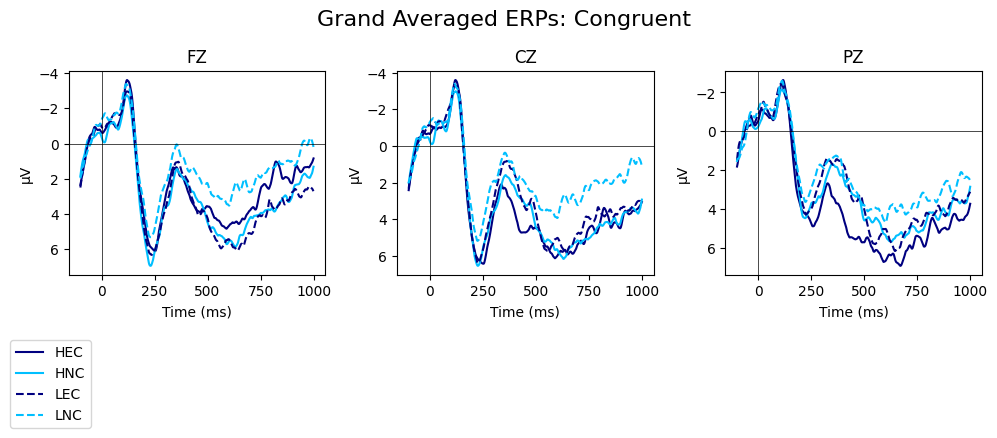

In [11]:
ch_dict = s.get_chan_dict()
bins_dict = {'HEC':0, 'HNC':1, 'LEC':2, 'LNC':3}
pred_names = pred1.columns.to_list()
pred_names.insert(0, 'Intercept')
effects_dict = {}
for i, x in enumerate(pred_names): effects_dict[x] = i

sg = stats_and_graphs(ch_dict, bins_dict, effects_dict, subj_outputs, subj_rerp_roi, gnd)
sg.plot_grand_averages('Grand Averaged ERPs: Congruent', 'ERP', row=1, col=3, figsize=(10,3), bins=['HEC', 'HNC', 'LEC', 'LNC'],
                    linestyles=['solid', 'solid', 'dashed', 'dashed'], colors=['navy','deepskyblue','navy', 'deepskyblue'],
                    chan_list=['FZ','CZ','PZ'], baseline=-100)

Uncorrected p-values



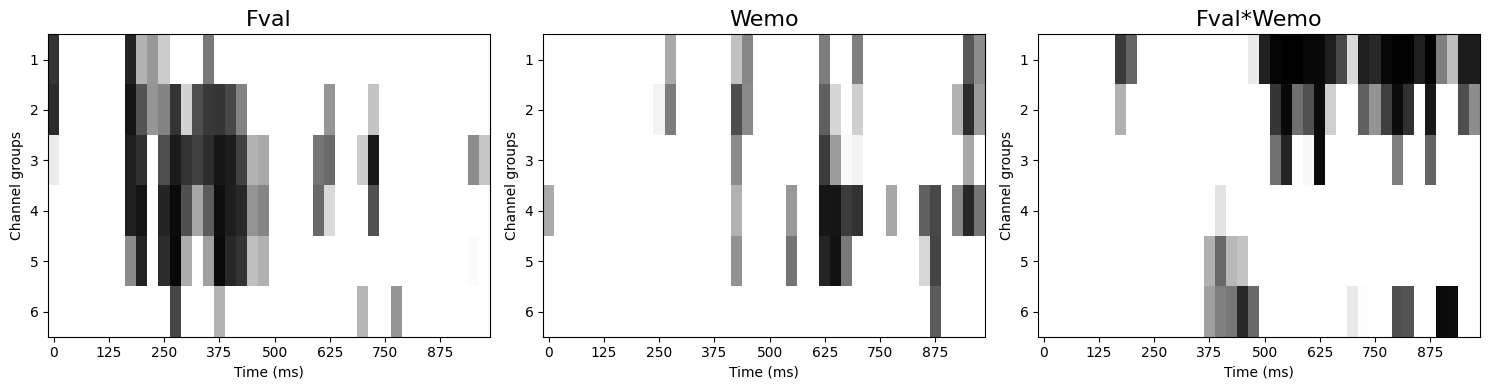

In [12]:
coeffs = sg.coeff_formatting()
tval, pval = sg.ttest(coeffs)
ttest_fdr = sg.fdr_BH(pval)

xticks = list(range(-125, 1000, 125))
yticks = list(range(0,7))
print('Uncorrected p-values\n')
sg.hypothesis_heat_maps(pval, row=1, col=3, pred_names=pred_names, figsize=(15,4), fontsize=16,
                        xticks=xticks, yticks=yticks, tmin=4, tmax=44)

Benjamin-Hochberg corrected q-values



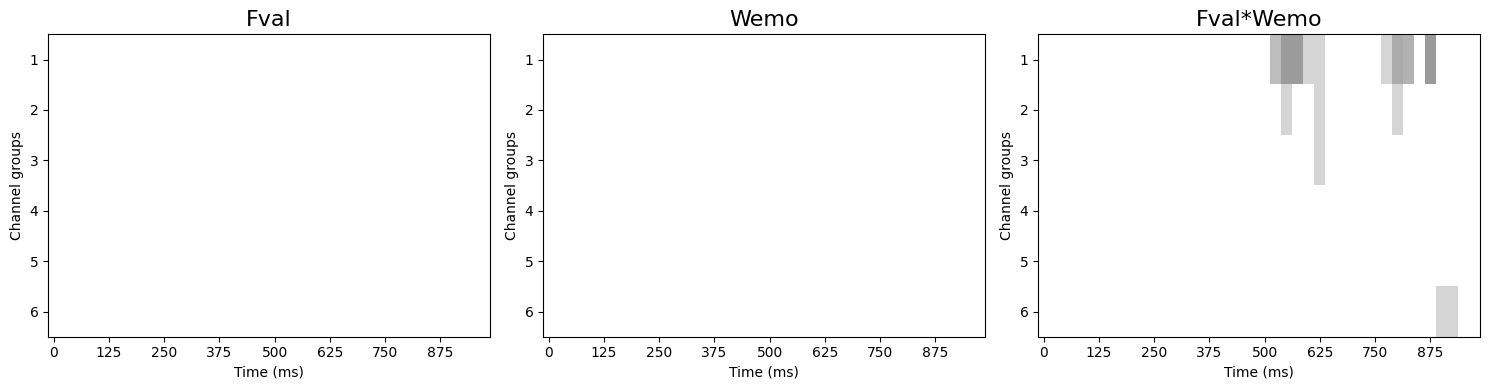

In [13]:
print('Benjamin-Hochberg corrected q-values\n')
sg.hypothesis_heat_maps(ttest_fdr.Qval, row=1, col=3, pred_names=pred_names, figsize=(15,4), fontsize=16,
                        xticks=xticks, yticks=yticks, tmin=4, tmax=44)

rERP Grand Averaged Significant Coefficients


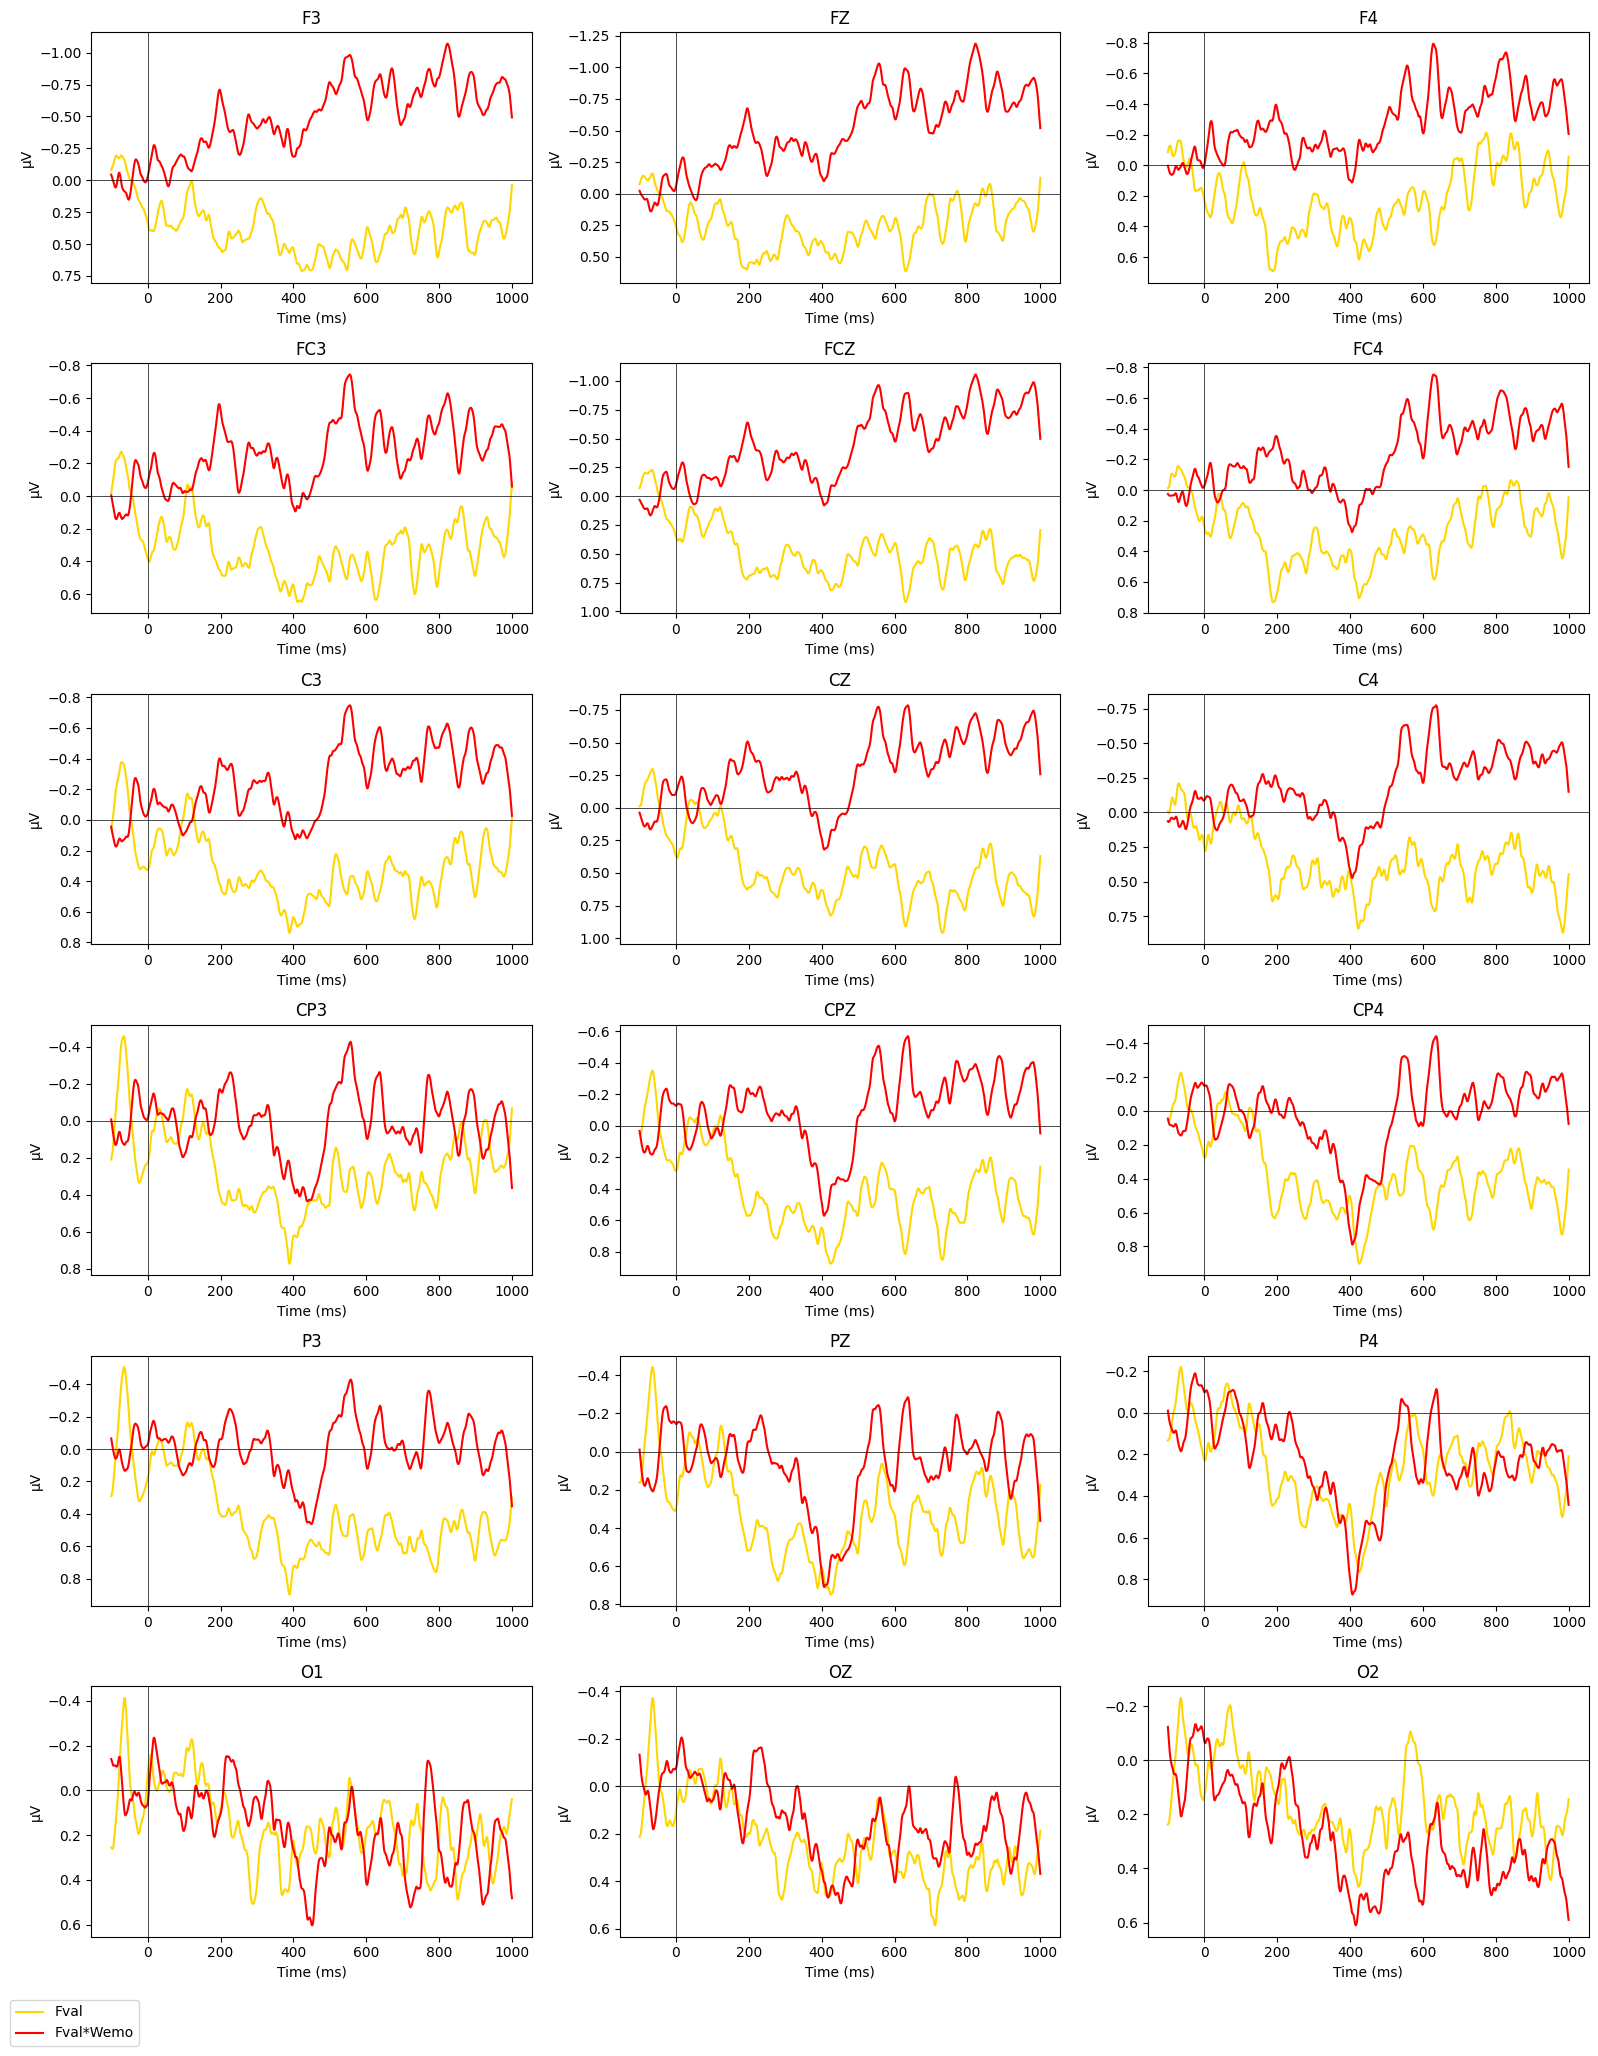

In [14]:
print('rERP Grand Averaged Significant Coefficients')
sg.plot_grand_averages(None, 'rERP', row=6, col=3, figsize=(16,20), bins=None,
                       effects=['Fval', 'Fval*Wemo'], linestyles= ['solid', 'solid', 'solid'], colors=['gold', 'red'],
                       chan_list=sum(rerp_roi_chan,[]), baseline=-100)